# **E-commerce data EDA for Customer Behavior Analysis**

EDA (Exploratory Data Analysis) of E-Commerce data will help us understand the data and think of ways to use it to understand the customer behavior.

# **1. Load libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as py
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve

# **2. Load Data**

In [2]:
dataset = pd.read_csv("/content/drive/MyDrive/Customer_Behavior_Data.csv", delimiter = ';')

# **3. EDA**

With every new dataset we need to got throuhg an EDA (Exploratory Data Analysis) process. It's a good idea to have a basic framework in mind for our EDAs. It is always a good idea to:

• Understand what our columns say

• Rename columns labels and make them lowercase

• Make sure that the data types of columns are correct

• Handle missing values

• Check for duplicates

• Search for outliers

• Check for linearity between variables

To achieve this we can take advantage of Pandas and visualisation libraries


In [3]:
dataset.head()

,account length,location code,user id,credit card info save,push status,add to wishlist,desktop sessions,app sessions,desktop transactions,total product detail views,session duration,promotion clicks,avg order value,sale product views,discount rate per visited products,product detail view per app session,app transactions,add to cart per session,customer service calls,"churn,,,,"
0,128,415,3824657,no,yes,25,265,45,17,110,197,87,"244,7",91,"11,01",10,3,"2,7",1,"0,"
1,107,415,3717191,no,yes,26,162,27,17,123,196,103,"254,4",103,"11,45","13,7",3,"3,7",1,0
2,137,415,3581921,no,no,0,243,41,10,114,121,110,"162,6",104,"7,32","12,2",5,"3,29",0,0
3,84,408,3759999,yes,no,0,299,51,5,71,62,88,"196,9",89,"8,86","6,6",7,"1,78",2,0
4,75,415,3306626,yes,no,0,167,28,13,113,148,122,"186,9",121,"8,41","10,1",3,"2,73",3,0


In [4]:
dataset.columns

Index(['account length', 'location code', 'user id', 'credit card info save',
       'push status', 'add to wishlist', 'desktop sessions', 'app sessions',
       'desktop transactions', 'total product detail views',
       'session duration', 'promotion clicks', 'avg order value',
       'sale product views', 'discount rate per visited products',
       'product detail view per app session', 'app transactions',
       'add to cart per session', 'customer service calls', 'churn,,,,'],
      dtype='object')

In [5]:
dataset.rename(columns={'churn,,,,':'churn'}, inplace=True)

In [6]:
dataset.rename(columns=lambda x: x.lower(), inplace=True)

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   account length                       3333 non-null   int64 
 1   location code                        3333 non-null   int64 
 2   user id                              3333 non-null   int64 
 3   credit card info save                3333 non-null   object
 4   push status                          3333 non-null   object
 5   add to wishlist                      3333 non-null   int64 
 6   desktop sessions                     3333 non-null   int64 
 7   app sessions                         3333 non-null   int64 
 8   desktop transactions                 3333 non-null   int64 
 9   total product detail views           3333 non-null   int64 
 10  session duration                     3333 non-null   int64 
 11  promotion clicks                     3333 n

In [8]:
dataset['avg order value'] = dataset['avg order value'].str.replace(',', '.')
dataset['discount rate per visited products'] = dataset['discount rate per visited products'].str.replace(',', '.')
dataset['product detail view per app session'] = dataset['product detail view per app session'].str.replace(',', '.')
dataset['add to cart per session'] = dataset['add to cart per session'].str.replace(',', '.')

In [9]:
dataset

,account length,location code,user id,credit card info save,push status,add to wishlist,desktop sessions,app sessions,desktop transactions,total product detail views,session duration,promotion clicks,avg order value,sale product views,discount rate per visited products,product detail view per app session,app transactions,add to cart per session,customer service calls,churn
0,128,415,3824657,no,yes,25,265,45,17,110,197,87,244.7,91,11.01,10,3,2.7,1,"0,"
1,107,415,3717191,no,yes,26,162,27,17,123,196,103,254.4,103,11.45,13.7,3,3.7,1,0
2,137,415,3581921,no,no,0,243,41,10,114,121,110,162.6,104,7.32,12.2,5,3.29,0,0
3,84,408,3759999,yes,no,0,299,51,5,71,62,88,196.9,89,8.86,6.6,7,1.78,2,0
4,75,415,3306626,yes,no,0,167,28,13,113,148,122,186.9,121,8.41,10.1,3,2.73,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,192,415,4144276,no,yes,36,156,27,18,77,216,126,279.1,83,12.56,9.9,6,2.67,2,0
3329,68,415,3703271,no,no,0,231,39,13,57,153,55,191.3,123,8.61,9.6,4,2.59,3,0
3330,28,510,3288230,no,no,0,181,31,25,109,289,58,191.9,91,8.64,14.1,6,3.81,2,0
3331,184,510,3646381,yes,no,0,214,36,14,105,160,84,139.2,137,6.26,5,10,1.35,2,"0,"


In [10]:
split_churn = dataset['churn'].str.split(',', expand = True)
dataset = pd.concat([dataset, split_churn], axis = 1)

In [11]:
dataset

,account length,location code,user id,credit card info save,push status,add to wishlist,desktop sessions,app sessions,desktop transactions,total product detail views,...,discount rate per visited products,product detail view per app session,app transactions,add to cart per session,customer service calls,churn,0,1,2,3
0,128,415,3824657,no,yes,25,265,45,17,110,...,11.01,10,3,2.7,1,"0,",0,,None,None
1,107,415,3717191,no,yes,26,162,27,17,123,...,11.45,13.7,3,3.7,1,0,0,None,None,None
2,137,415,3581921,no,no,0,243,41,10,114,...,7.32,12.2,5,3.29,0,0,0,None,None,None
3,84,408,3759999,yes,no,0,299,51,5,71,...,8.86,6.6,7,1.78,2,0,0,None,None,None
4,75,415,3306626,yes,no,0,167,28,13,113,...,8.41,10.1,3,2.73,3,0,0,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,192,415,4144276,no,yes,36,156,27,18,77,...,12.56,9.9,6,2.67,2,0,0,None,None,None
3329,68,415,3703271,no,no,0,231,39,13,57,...,8.61,9.6,4,2.59,3,0,0,None,None,None
3330,28,510,3288230,no,no,0,181,31,25,109,...,8.64,14.1,6,3.81,2,0,0,None,None,None
3331,184,510,3646381,yes,no,0,214,36,14,105,...,6.26,5,10,1.35,2,"0,",0,,None,None


In [12]:
dataset['location code'].unique()

array([415, 408, 510])

In [13]:
drop_col = ['churn', 1, 2, 3]
dataset.drop(columns=drop_col, inplace = True)

In [14]:
dataset

,account length,location code,user id,credit card info save,push status,add to wishlist,desktop sessions,app sessions,desktop transactions,total product detail views,session duration,promotion clicks,avg order value,sale product views,discount rate per visited products,product detail view per app session,app transactions,add to cart per session,customer service calls,0
0,128,415,3824657,no,yes,25,265,45,17,110,197,87,244.7,91,11.01,10,3,2.7,1,0
1,107,415,3717191,no,yes,26,162,27,17,123,196,103,254.4,103,11.45,13.7,3,3.7,1,0
2,137,415,3581921,no,no,0,243,41,10,114,121,110,162.6,104,7.32,12.2,5,3.29,0,0
3,84,408,3759999,yes,no,0,299,51,5,71,62,88,196.9,89,8.86,6.6,7,1.78,2,0
4,75,415,3306626,yes,no,0,167,28,13,113,148,122,186.9,121,8.41,10.1,3,2.73,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,192,415,4144276,no,yes,36,156,27,18,77,216,126,279.1,83,12.56,9.9,6,2.67,2,0
3329,68,415,3703271,no,no,0,231,39,13,57,153,55,191.3,123,8.61,9.6,4,2.59,3,0
3330,28,510,3288230,no,no,0,181,31,25,109,289,58,191.9,91,8.64,14.1,6,3.81,2,0
3331,184,510,3646381,yes,no,0,214,36,14,105,160,84,139.2,137,6.26,5,10,1.35,2,0


In [15]:
dataset.rename(columns = {0:'churn'}, inplace = True)

# **4. Statistical Analysis**

In [16]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   account length                       3333 non-null   int64 
 1   location code                        3333 non-null   int64 
 2   user id                              3333 non-null   int64 
 3   credit card info save                3333 non-null   object
 4   push status                          3333 non-null   object
 5   add to wishlist                      3333 non-null   int64 
 6   desktop sessions                     3333 non-null   int64 
 7   app sessions                         3333 non-null   int64 
 8   desktop transactions                 3333 non-null   int64 
 9   total product detail views           3333 non-null   int64 
 10  session duration                     3333 non-null   int64 
 11  promotion clicks                     3333 n

In [17]:
dataset['avg order value'] = dataset['avg order value'].astype('float64')
dataset['discount rate per visited products'] = dataset['discount rate per visited products'].astype('float64')
dataset['product detail view per app session'] = dataset['product detail view per app session'].astype('float64')
dataset['add to cart per session'] = dataset['add to cart per session'].astype('float64')
dataset['location code'] = dataset['location code'].astype('category')
dataset['churn'] = dataset['churn'].astype('int64')

In [18]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   account length                       3333 non-null   int64   
 1   location code                        3333 non-null   category
 2   user id                              3333 non-null   int64   
 3   credit card info save                3333 non-null   object  
 4   push status                          3333 non-null   object  
 5   add to wishlist                      3333 non-null   int64   
 6   desktop sessions                     3333 non-null   int64   
 7   app sessions                         3333 non-null   int64   
 8   desktop transactions                 3333 non-null   int64   
 9   total product detail views           3333 non-null   int64   
 10  session duration                     3333 non-null   int64   
 11  promotion clicks 

In [19]:
dataset.isnull().sum()

account length                         0
location code                          0
user id                                0
credit card info save                  0
push status                            0
add to wishlist                        0
desktop sessions                       0
app sessions                           0
desktop transactions                   0
total product detail views             0
session duration                       0
promotion clicks                       0
avg order value                        0
sale product views                     0
discount rate per visited products     0
product detail view per app session    0
app transactions                       0
add to cart per session                0
customer service calls                 0
churn                                  0
dtype: int64

In [20]:
duplicate_record = dataset.duplicated()
dataset[duplicate_record]

,account length,location code,user id,credit card info save,push status,add to wishlist,desktop sessions,app sessions,desktop transactions,total product detail views,session duration,promotion clicks,avg order value,sale product views,discount rate per visited products,product detail view per app session,app transactions,add to cart per session,customer service calls,churn


In [21]:
dataset.duplicated().sum()

0

In [22]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
account length,3333.0,1.010648e+02,39.822106,1.00,74.00,101.00,127.00,243.00
user id,3333.0,3.746291e+06,274662.573752,3271058.00,3508680.00,3748187.00,3985970.00,4229964.00
add to wishlist,3333.0,8.099010e+00,13.688365,0.00,0.00,0.00,20.00,51.00
desktop sessions,3333.0,1.798119e+02,54.457135,0.00,144.00,179.00,216.00,351.00
app sessions,3333.0,3.056796e+01,9.269376,0.00,24.00,31.00,37.00,60.00
desktop transactions,3333.0,1.708761e+01,4.323795,0.00,14.00,17.00,20.00,31.00
total product detail views,3333.0,1.004356e+02,20.069084,0.00,87.00,101.00,114.00,165.00
session duration,3333.0,2.010396e+02,50.714359,0.00,167.00,201.00,235.00,364.00
promotion clicks,3333.0,1.001107e+02,19.923911,0.00,87.00,100.00,114.00,170.00
avg order value,3333.0,2.008720e+02,50.573847,23.20,167.00,201.20,235.30,395.00


# **5. Identify Outliers**

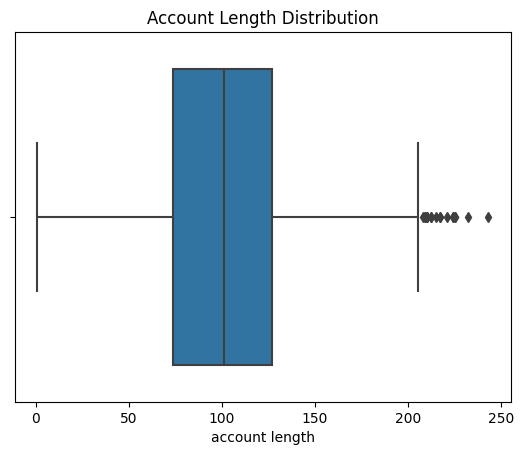

In [23]:
sns.boxplot(x=dataset['account length'])
py.title('Account Length Distribution')
py.show()

**The account length has outlier above the upper limit.**

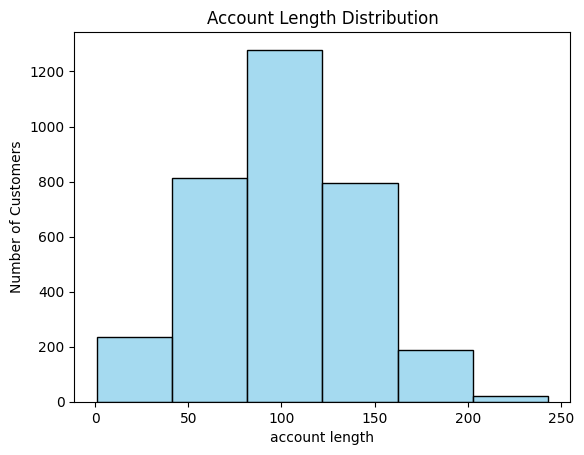

In [24]:
sns.histplot(x = dataset['account length'], bins=6, kde=False, color='skyblue')
py.title('Account Length Distribution')
py.ylabel('Number of Customers')
py.show()

**Account Length has nearly normal distribution.**

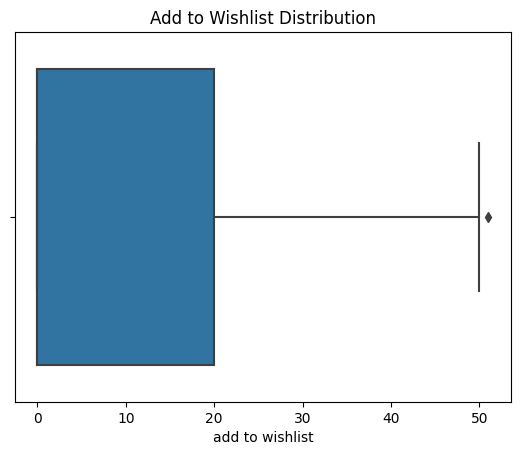

In [25]:
sns.boxplot(x=dataset['add to wishlist'])
py.title('Add to Wishlist Distribution')
py.show()

**Add to wishlist has only one outlier above the upper limit.**

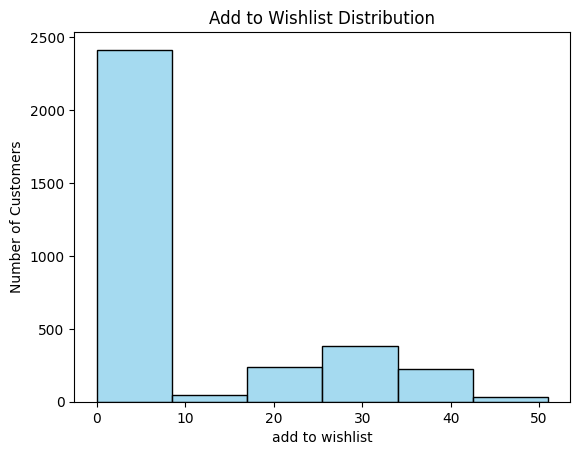

In [26]:
sns.histplot(x = dataset['add to wishlist'], bins=6, kde=False, color='skyblue')
py.title('Add to Wishlist Distribution')
py.ylabel('Number of Customers')
py.show()

**Its distribution is right-skewed and imbalance.**

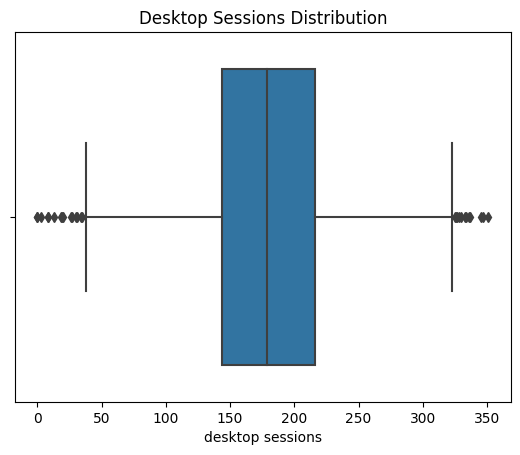

In [27]:
sns.boxplot(x=dataset['desktop sessions'])
py.title('Desktop Sessions Distribution')
py.show()

**Desktop Sessions has outlier both below the lower limit and above the upper limit.**

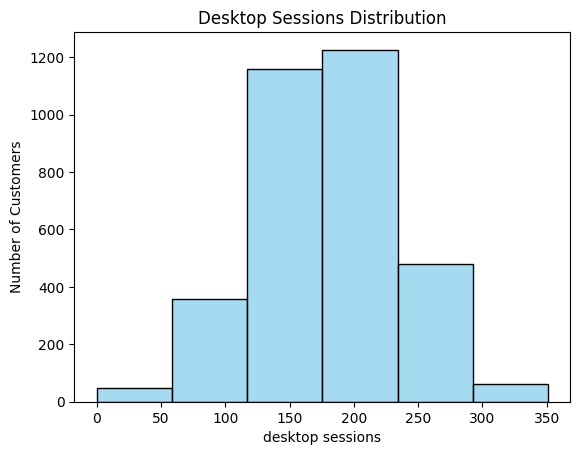

In [28]:
sns.histplot(x = dataset['desktop sessions'], bins=6, kde=False, color='skyblue')
py.title('Desktop Sessions Distribution')
py.ylabel('Number of Customers')
py.show()

**This histogram incidated the nearly normal distribution.**

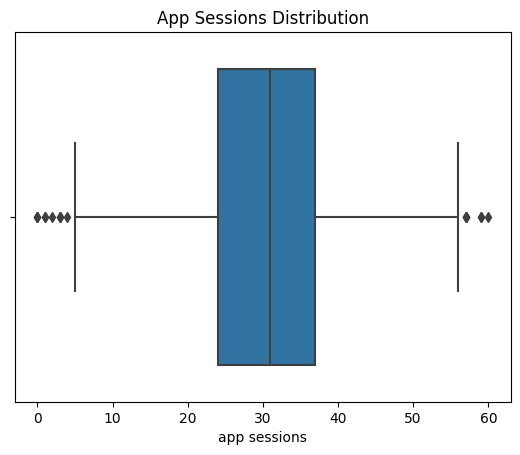

In [29]:
sns.boxplot(x=dataset['app sessions'])
py.title('App Sessions Distribution')
py.show()

**This box plot displays the outlier at both ends but there are more outlier that are below the lower limit than those that are above the upper limit.**

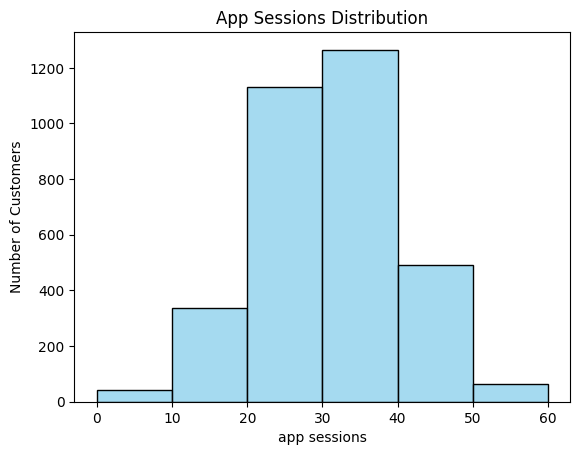

In [30]:
sns.histplot(x = dataset['app sessions'], bins=6, kde=False, color='skyblue')
py.title('App Sessions Distribution')
py.ylabel('Number of Customers')
py.show()

**This histogram is nearly normal distribution. The median must be slighty towards right side.**

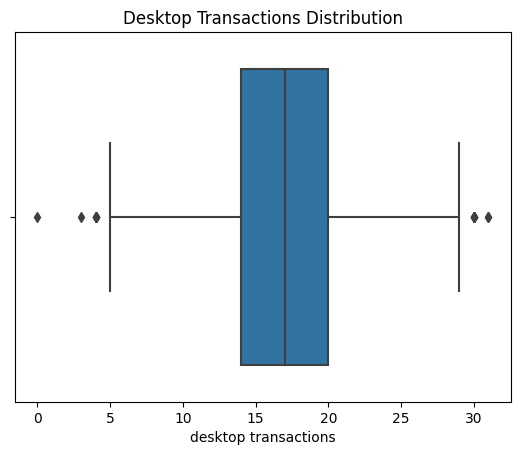

In [31]:
sns.boxplot(x=dataset['desktop transactions'])
py.title('Desktop Transactions Distribution')
py.show()

**This plot has few outliers at each end. Also, the median is nearly at the center of the box.**

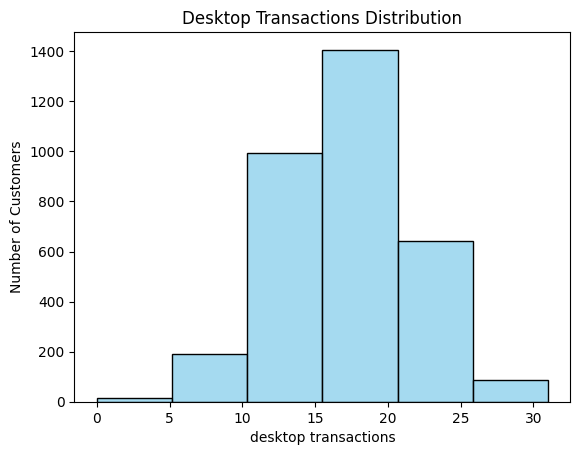

In [32]:
sns.histplot(x = dataset['desktop transactions'], bins=6, kde=False, color='skyblue')
py.title('Desktop Transactions Distribution')
py.ylabel('Number of Customers')
py.show()

**The distribution is nearly normal.**

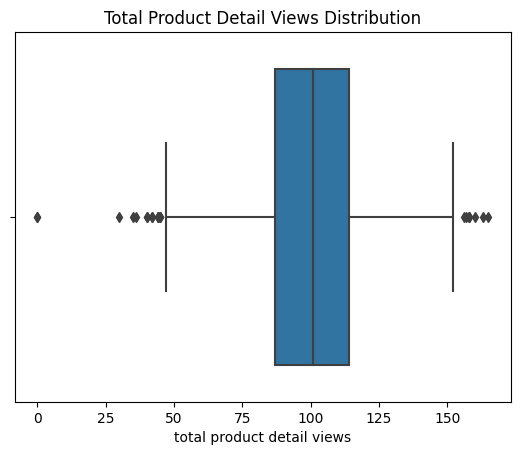

In [33]:
sns.boxplot(x=dataset['total product detail views'])
py.title('Total Product Detail Views Distribution')
py.show()

**There are outlier at both ends. Also, the median lies at the center.**

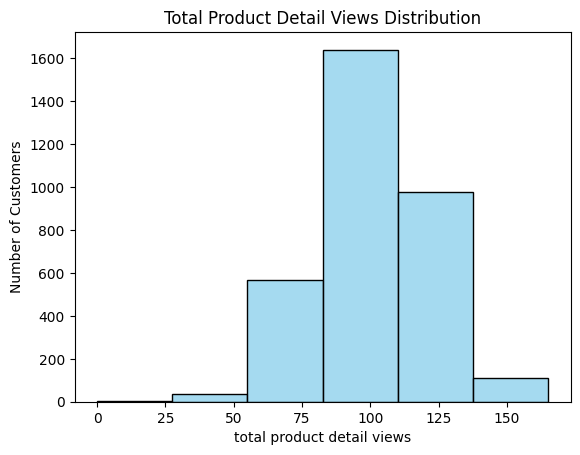

In [34]:
sns.histplot(x = dataset['total product detail views'], bins=6, kde=False, color='skyblue')
py.title('Total Product Detail Views Distribution')
py.ylabel('Number of Customers')
py.show()

**This histogram shows a normal distribution of total product detail views**

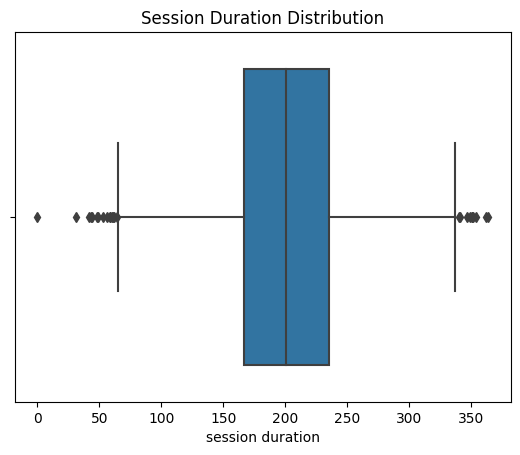

In [35]:
sns.boxplot(x=dataset['session duration'])
py.title('Session Duration Distribution')
py.show()

**This boxplot has outliers at both ends but one outlier is extremely below the lower limit. Also, the median lies at the center.**

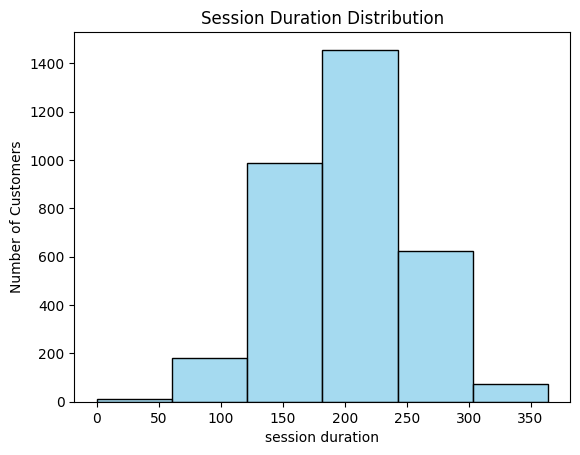

In [36]:
sns.histplot(x = dataset['session duration'], bins=6, kde=False, color='skyblue')
py.title('Session Duration Distribution')
py.ylabel('Number of Customers')
py.show()

**This histogram shows nearly normal distribution**

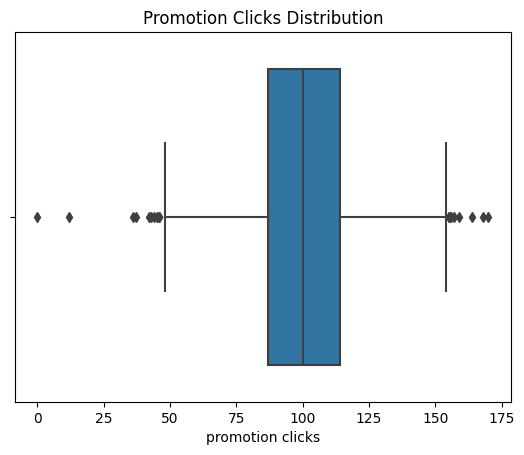

In [37]:
sns.boxplot(x=dataset['promotion clicks'])
py.title('Promotion Clicks Distribution')
py.show()

**This boxplot display the outlier at both ends but there are few outlier which are far below the lower limit. Moreover, the median lies at the center.**

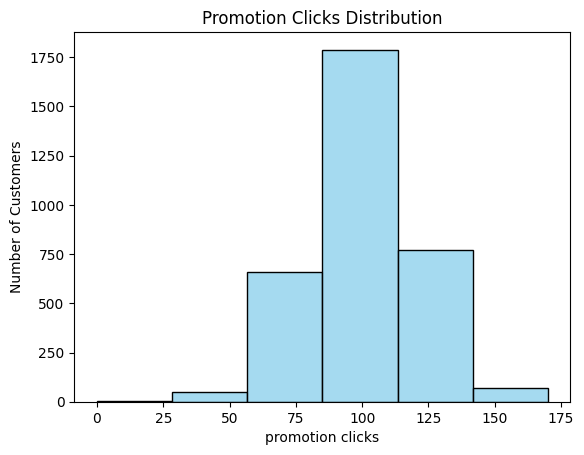

In [38]:
sns.histplot(x = dataset['promotion clicks'], bins=6, kde=False, color='skyblue')
py.title('Promotion Clicks Distribution')
py.ylabel('Number of Customers')
py.show()

**This histogram shows the nearly normal distribution.**

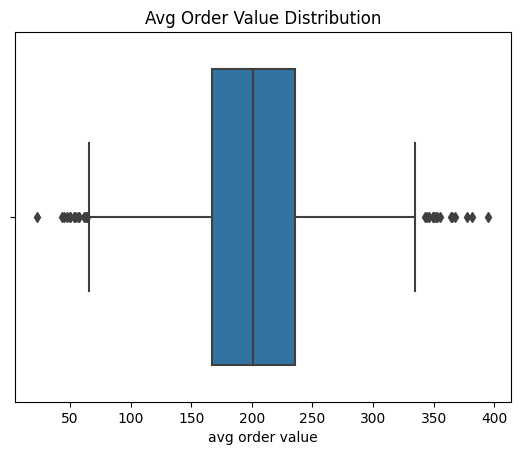

In [39]:
sns.boxplot(x=dataset['avg order value'])
py.title('Avg Order Value Distribution')
py.show()

**This boxplot has outliers at both ends but the ones above the upper limit are slightly farther. Also, the median is at the center.**

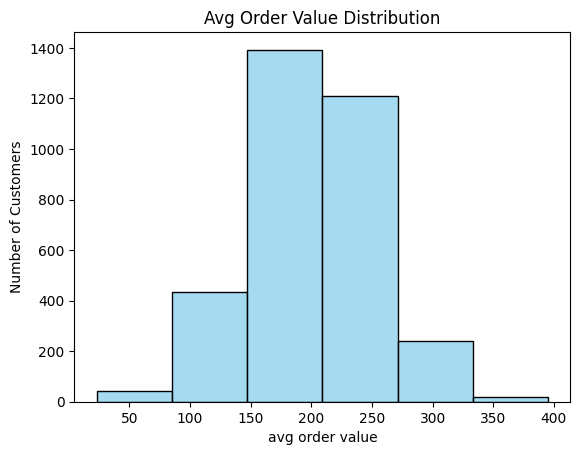

In [40]:
sns.histplot(x = dataset['avg order value'], bins=6, kde=False, color='skyblue')
py.title('Avg Order Value Distribution')
py.ylabel('Number of Customers')
py.show()

**This histogram shows that the distribution is nearly normal.**

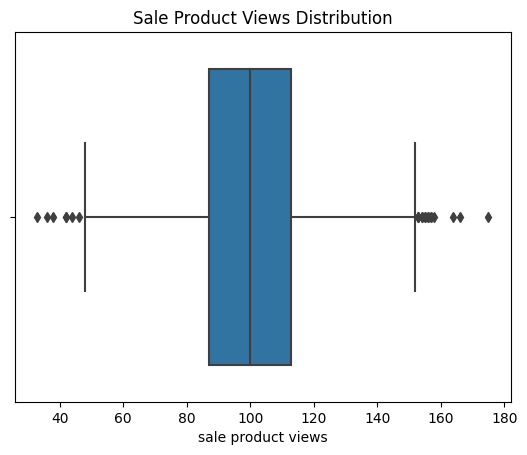

In [41]:
sns.boxplot(x=dataset['sale product views'])
py.title('Sale Product Views Distribution')
py.show()

**This boxplot has outliers at both ends and the median lies at the center.**

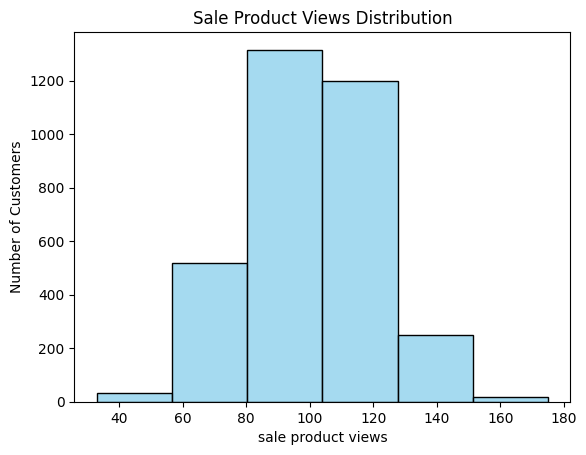

In [42]:
sns.histplot(x = dataset['sale product views'], bins=6, kde=False, color='skyblue')
py.title('Sale Product Views Distribution')
py.ylabel('Number of Customers')
py.show()

**This distribution is nearly normal**

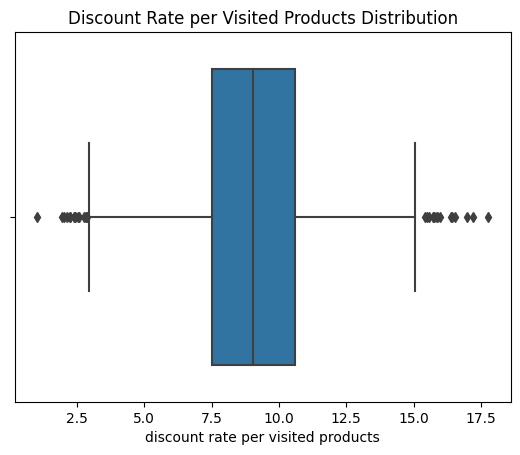

In [43]:
sns.boxplot(x=dataset['discount rate per visited products'])
py.title('Discount Rate per Visited Products Distribution')
py.show()

**This boxplot has outliers at both ends and median lies at the center.**

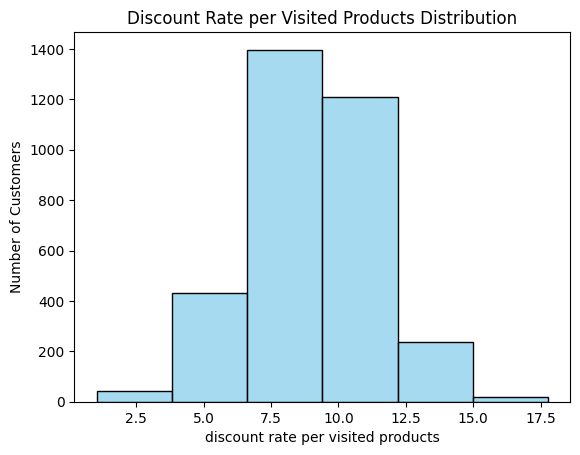

In [44]:
sns.histplot(x = dataset['discount rate per visited products'], bins=6, kde=False, color='skyblue')
py.title('Discount Rate per Visited Products Distribution')
py.ylabel('Number of Customers')
py.show()

**This histogram has nearly normal distribution.**

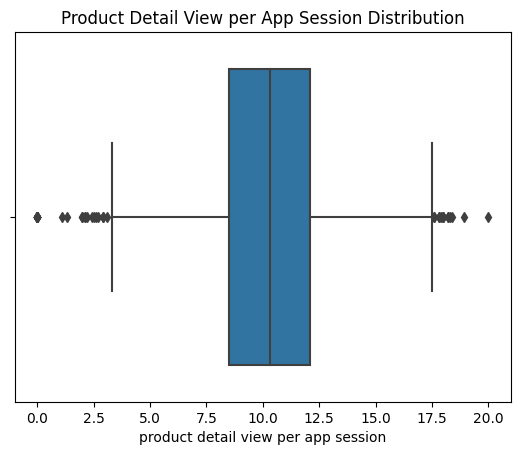

In [45]:
sns.boxplot(x=dataset['product detail view per app session'])
py.title('Product Detail View per App Session Distribution')
py.show()

**This boxplot has outlier at both ends and median lies at the center.**

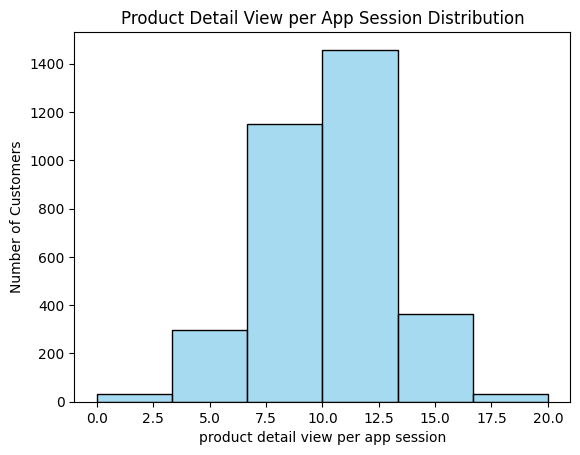

In [46]:
sns.histplot(x = dataset['product detail view per app session'], bins=6, kde=False, color='skyblue')
py.title('Product Detail View per App Session Distribution')
py.ylabel('Number of Customers')
py.show()

**This histogram has nearly normal distribution.**

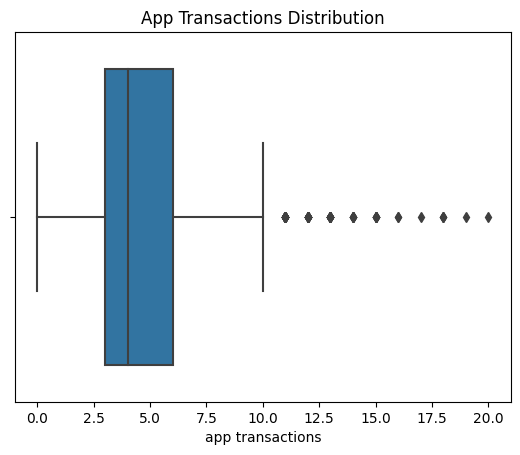

In [47]:
sns.boxplot(x=dataset['app transactions'])
py.title('App Transactions Distribution')
py.show()

**All the outliers are above the upper limit. Also, the median lies at the left side.**

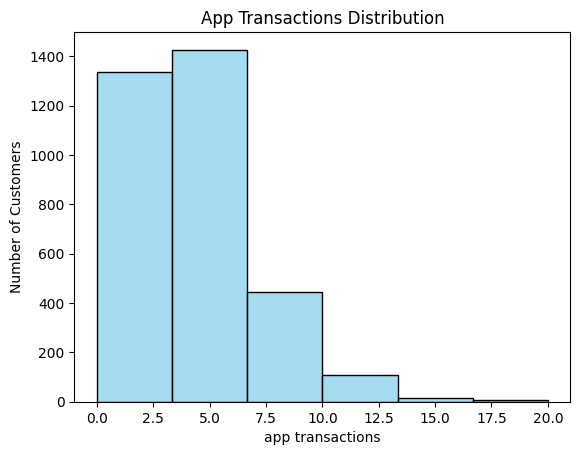

In [48]:
sns.histplot(x = dataset['app transactions'], bins=6, kde=False, color='skyblue')
py.title('App Transactions Distribution')
py.ylabel('Number of Customers')
py.show()

**This distribution is right-skewed and is imbalanced.**

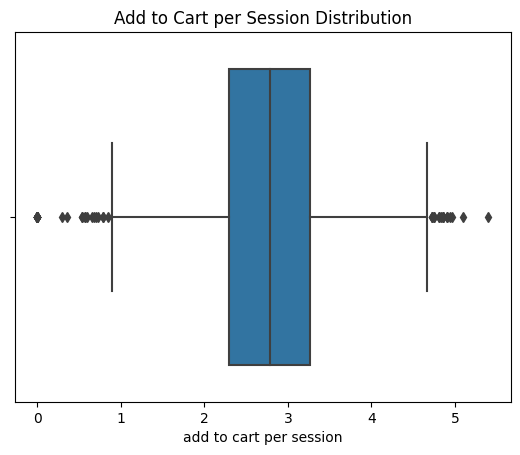

In [49]:
sns.boxplot(x=dataset['add to cart per session'])
py.title('Add to Cart per Session Distribution')
py.show()

**The outliers are at both ends and the median lies at the center.**

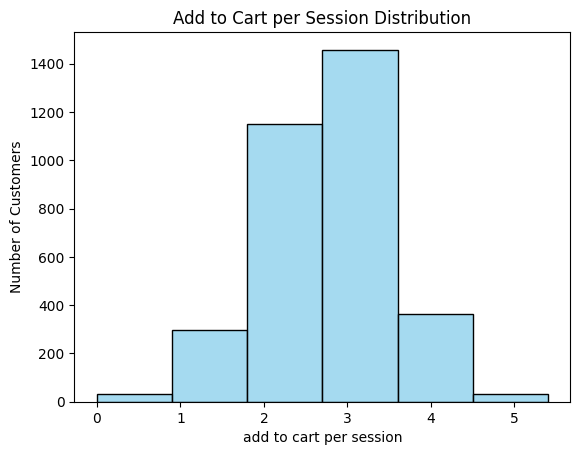

In [50]:
sns.histplot(x = dataset['add to cart per session'], bins=6, kde=False, color='skyblue')
py.title('Add to Cart per Session Distribution')
py.ylabel('Number of Customers')
py.show()

**This distribution is nearly normal.**

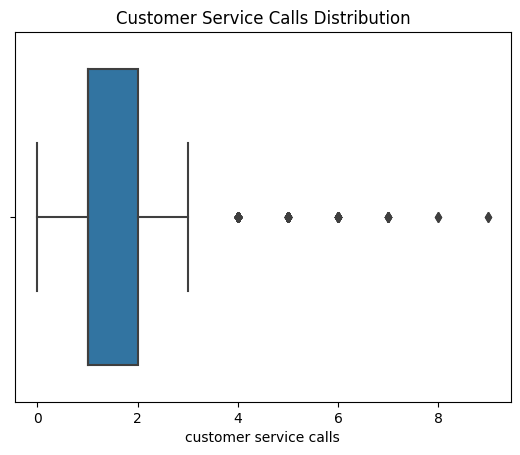

In [51]:
sns.boxplot(x=dataset['customer service calls'])
py.title('Customer Service Calls Distribution')
py.show()

**This boxplot has outliers above the upper limit and the median lies at extreme left.**

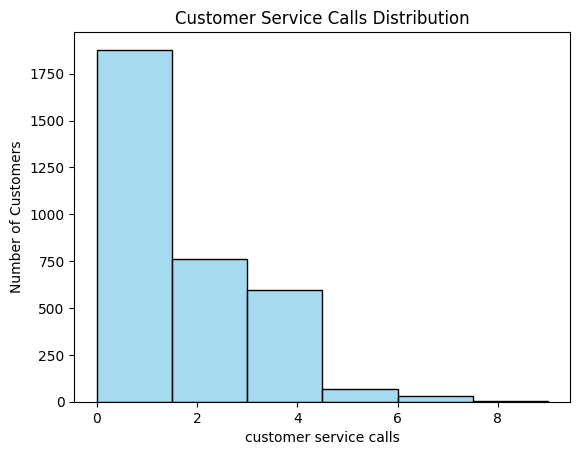

In [52]:
sns.histplot(x = dataset['customer service calls'], bins=6, kde=False, color='skyblue')
py.title('Customer Service Calls Distribution')
py.ylabel('Number of Customers')
py.show()

**The distribution of this histogram is right-skewed and imbalanced.**

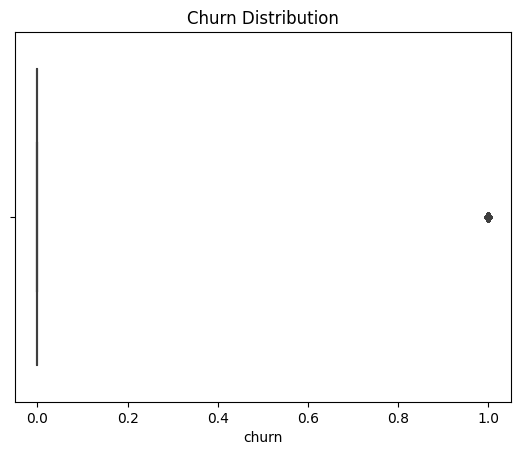

In [53]:
sns.boxplot(x=dataset['churn'])
py.title('Churn Distribution')
py.show()

**This boxplot has zero has it's lower limit and upper limit with 1 as an outlier and median is also zero.**

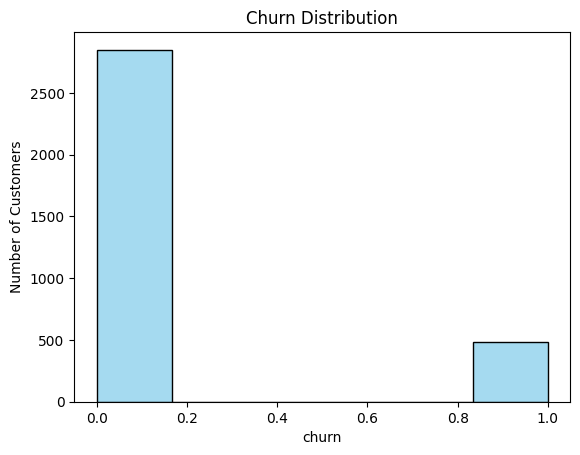

In [54]:
sns.histplot(x = dataset['churn'], bins=6, kde=False, color='skyblue')
py.title('Churn Distribution')
py.ylabel('Number of Customers')
py.show()

**The distribution of this histogram is right-skewed and imbalanced.**

# **6. Correlation Matrix**

<ipython-input-55-da89990f26ff>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation = dataset.corr()


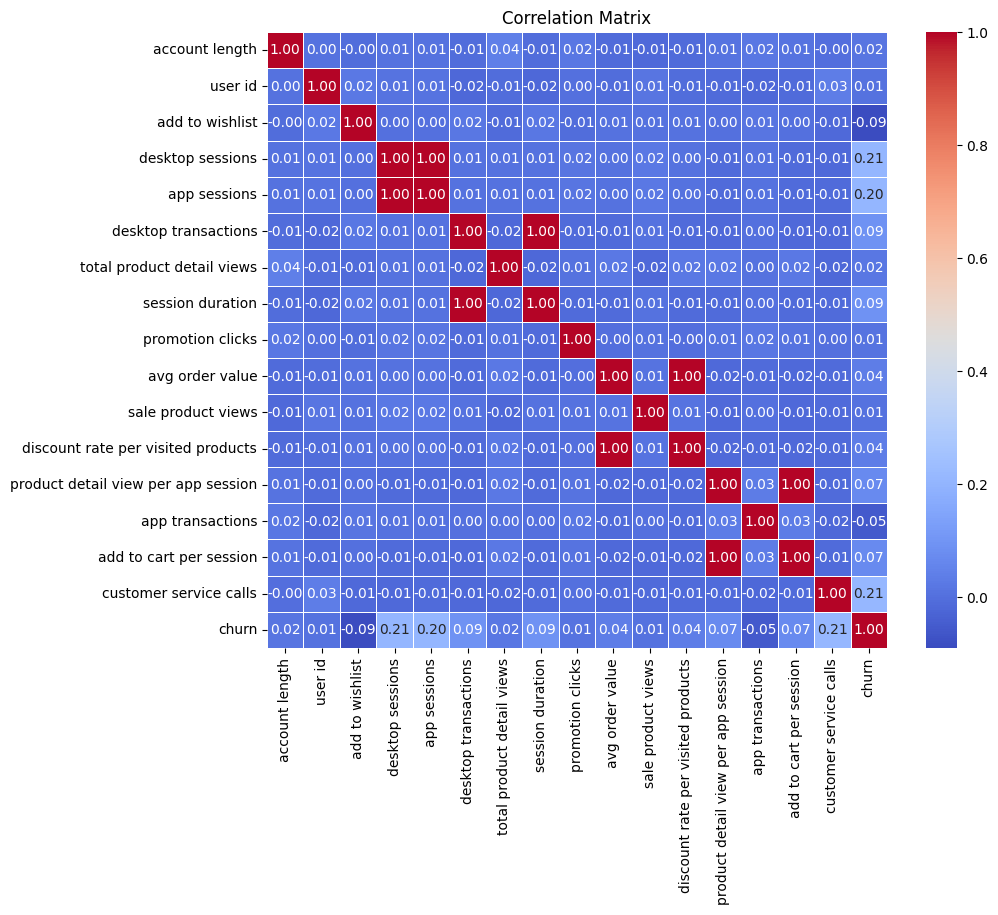

In [55]:
correlation = dataset.corr()
py.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
py.title('Correlation Matrix')
py.show()

# **7. Numerical Vs Churn**

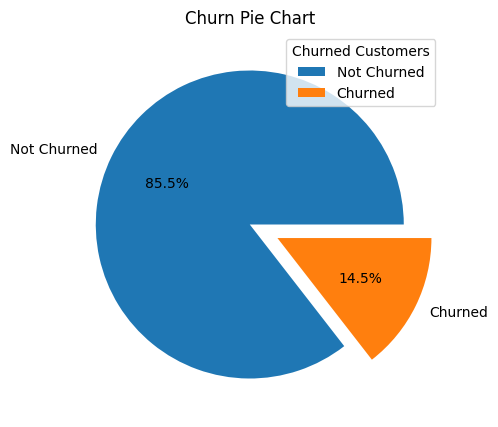

In [56]:
x_labels = ['Not Churned', 'Churned']
churn_explode = [0, 0.2]
churn_count = dataset['churn'].value_counts()
py.figure(figsize=(5, 5))
py.pie(churn_count, labels = x_labels, autopct ='%1.1f%%', startangle = 0, explode = churn_explode)
py.title('Churn Pie Chart')
py.legend(loc='upper right', title = 'Churned Customers')
py.show()

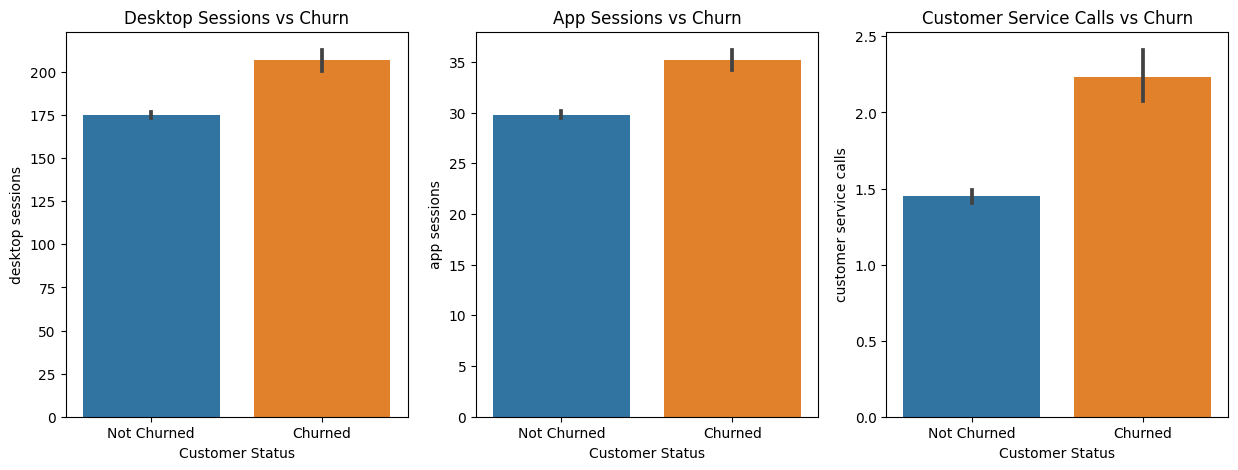

In [57]:
x = dataset['churn'].unique()
py.figure(figsize=(15, 5))
py.subplot(1, 3, 1)
sns.barplot(x = 'churn', y = 'desktop sessions', data = dataset)
py.title('Desktop Sessions vs Churn')
py.xticks(x, x_labels)
py.xlabel('Customer Status')
py.subplot(1, 3, 2)
sns.barplot(x = 'churn', y = 'app sessions', data = dataset)
py.title('App Sessions vs Churn')
py.xticks(x, x_labels)
py.xlabel('Customer Status')
py.subplot(1, 3, 3)
sns.barplot(x = 'churn', y = 'customer service calls', data = dataset)
py.title('Customer Service Calls vs Churn')
py.xticks(x, x_labels)
py.xlabel('Customer Status')
py.show()


# **8. Categorical Vs Churn**

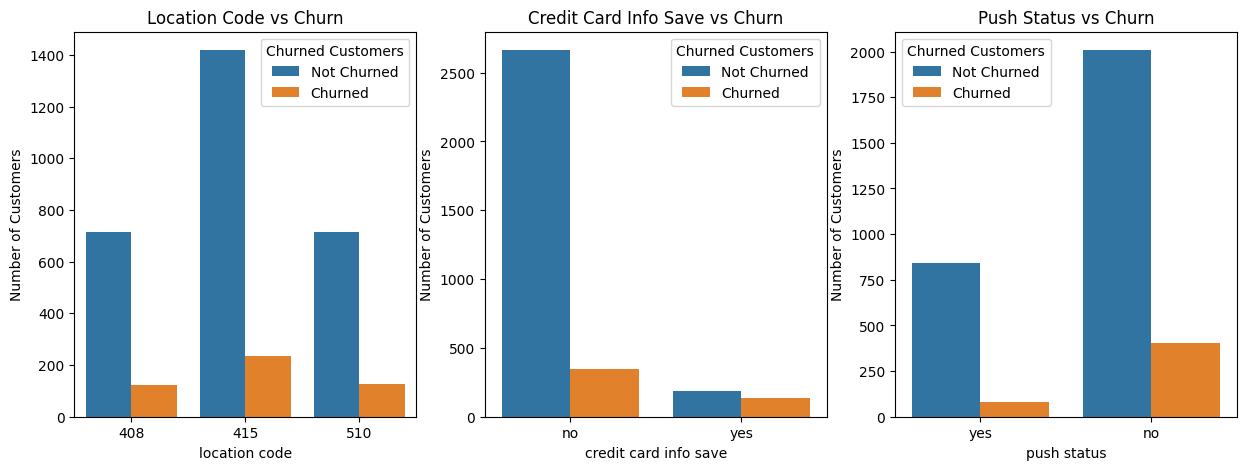

In [58]:
py.figure(figsize=(15, 5))
py.subplot(1, 3, 1)
sns.countplot(x='location code', hue='churn', data=dataset)
py.title('Location Code vs Churn')
py.legend(x_labels, title = 'Churned Customers')
py.ylabel('Number of Customers')
py.subplot(1, 3, 2)
sns.countplot(x='credit card info save', hue='churn', data=dataset)
py.title('Credit Card Info Save vs Churn')
py.legend(x_labels, title = 'Churned Customers')
py.ylabel('Number of Customers')
py.subplot(1, 3, 3)
sns.countplot(x='push status', hue='churn', data=dataset)
py.title('Push Status vs Churn')
py.legend(x_labels, title = 'Churned Customers')
py.ylabel('Number of Customers')
py.show()

# **9. Data Preprocessing**

In [59]:
encoder = LabelEncoder()
dataset['location code'] = encoder.fit_transform(dataset['location code'])

In [60]:
dataset['credit card info save'] = encoder.fit_transform(dataset['credit card info save'])

In [61]:
dataset['push status'] = encoder.fit_transform(dataset['push status'])

# **10. Model Creation**

In [62]:
X = dataset[['account length', 'location code', 'user id', 'credit card info save',
             'push status', 'add to wishlist', 'desktop sessions', 'app sessions',
             'desktop transactions', 'total product detail views',
             'session duration', 'promotion clicks', 'avg order value',
             'sale product views', 'discount rate per visited products',
             'product detail view per app session', 'app transactions',
             'add to cart per session', 'customer service calls']]

In [63]:
y = dataset['churn']

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=56)

In [65]:
clf = RandomForestClassifier(n_estimators=100, n_jobs= -1, random_state=56)
clf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=56)

In [66]:
predictions = clf.predict(X_test)

In [67]:
report = classification_report(y_test, predictions)
print(f'Classification Report:\n{report}')

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       586
           1       0.93      0.78      0.85        81

    accuracy                           0.97       667
   macro avg       0.95      0.88      0.91       667
weighted avg       0.96      0.97      0.96       667



# **11. Metrics Used**

In [68]:
auc_roc_score = roc_auc_score(y_test, predictions)
print(auc_roc_score)

0.8846226772847933


In [69]:
fpr, tpr, thresholds = roc_curve(y_test, predictions)

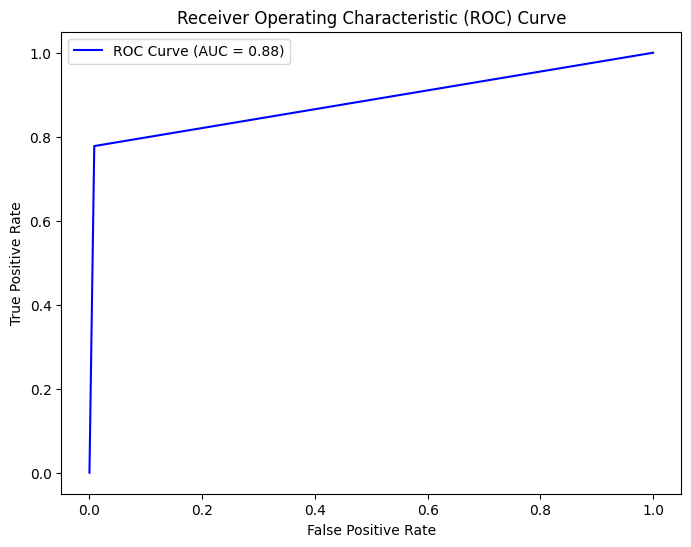

In [70]:
py.figure(figsize=(8, 6))
py.plot(fpr, tpr, color='blue', label='ROC Curve (AUC = {:.2f})'.format(auc_roc_score))
py.xlabel('False Positive Rate')
py.ylabel('True Positive Rate')
py.title('Receiver Operating Characteristic (ROC) Curve')
py.legend()
py.show()

**Reference: - https://www.w3schools.com/python/python_ml_auc_roc.asp**